# Phase 4: Has the CBD recovered, and has the working week changed shape?

**Question.** Compared with 2019, is CBD foot traffic back? Are Mondays and Fridays
further behind than the middle of the week, as you'd expect if hybrid workers
stay home at the edges of the week?

**Design**
- **Periods:** all of 2019 vs. Oct 2024 – Sep 2026 (two full recent years).
  The Nov 2022 – Sep 2024 data isn't published, and 2020–22 is lockdown and recovery.
- **Same sensors:** the 18 CBD sensors chosen in Phase 2.
- **Unit:** one sensor-day. Whole days only; public holidays and faulty
  sensor-days (all-zero daytimes) removed.
- **Model:** `log(count) ~ sensor + month + weekday × period`. Logging turns effects
  into ratios ("Fridays are at 0.75 of 2019"); sensor and month terms compare like
  with like. 95% intervals use standard errors clustered by week.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from melbourne_foot_traffic import analysis as A, config

con = duckdb.connect(str(config.DB_PATH), read_only=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK2,
    "lines.linewidth": 2, "font.size": 10, "figure.dpi": 110,
})
pct = lambda x: f"{x:.0%}"

days = A.sensor_days(con)
names = con.sql("SELECT location_id AS sensor_id, sensor_description AS name FROM sensors").df().set_index("sensor_id").name
print(f"{len(days):,} sensor-days:", days.groupby("period").size().to_dict())

17,951 sensor-days: {'2019': 6253, 'recent': 11698}


## 1. Overall: weekends are back, weekdays aren't

In [2]:
all_fit = A.fit_recovery(days)
A.by_weekday(all_fit).map(pct)

,ratio,low,high
Mon,72%,70%,74%
Tue,77%,75%,78%
Wed,76%,74%,78%
Thu,79%,77%,81%
Fri,75%,72%,77%
Sat,101%,97%,104%
Sun,101%,98%,104%


## 2. Two kinds of sensor

Some sensors sit among office towers (Collins Place, Spencer St, Queen St); others
in shopping and leisure areas (Bourke St Mall, Chinatown, Melbourne Central).
To avoid choosing by hand, sensors are classed by their **2019 weekday-to-weekend
ratio**: if weekday traffic was 30%+ above weekend traffic, the sensor is
"office". There's a clear break between 1.24 and 1.44, so the exact cut-off
barely matters.

In [3]:
types = A.classify_sensors(days).join(names)
office_ids = types.index[types.type == "office"]
types.round(2)

,weekday_vs_weekend_2019,type,name
sensor_id,,,
20,0.80,retail/leisure,Chinatown-Lt Bourke St (South)
30,0.85,retail/leisure,Lonsdale St (South)
19,0.85,retail/leisure,Chinatown-Swanston St (North)
5,0.93,retail/leisure,Princes Bridge
21,0.94,retail/leisure,155-161 Russell Street
3,0.98,retail/leisure,Melbourne Central
4,1.06,retail/leisure,Town Hall (West)
2,1.09,retail/leisure,Bourke Street Mall (South)
52,1.16,retail/leisure,Elizabeth St-Lonsdale St (South)


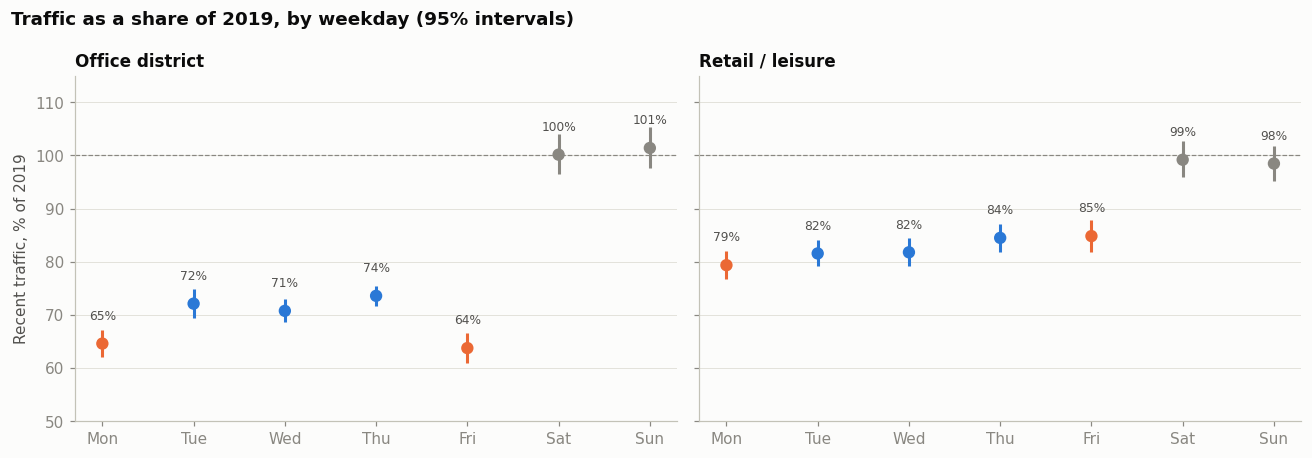

In [4]:
groups = {
    "Office district": days[days.sensor_id.isin(office_ids)],
    "Retail / leisure": days[~days.sensor_id.isin(office_ids)],
}
fits = {g: A.fit_recovery(d) for g, d in groups.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, (g, f) in zip(axes, fits.items()):
    r = A.by_weekday(f) * 100
    colours = [ORANGE if d in ("Mon", "Fri") else (MUTED if d in ("Sat", "Sun") else BLUE) for d in r.index]
    ax.vlines(r.index, r.low, r.high, color=colours, lw=2)
    ax.scatter(r.index, r.ratio, color=colours, s=50, zorder=3)
    for x, v in zip(r.index, r.ratio):
        ax.text(x, v + 4.5, f"{v:.0f}%", ha="center", fontsize=8, color=INK2)
    ax.axhline(100, color=MUTED, lw=0.8, ls="--")
    ax.set_title(g, fontsize=11)
    ax.set_ylim(50, 115)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Recent traffic, % of 2019")
fig.suptitle("Traffic as a share of 2019, by weekday (95% intervals)", x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()

## 3. Time of day

The same model, run separately on four time windows. If hybrid work is the cause,
the gap between Mon/Fri and Tue–Thu should be largest in the **morning commute**
and disappear in the **evening**, when people come in for leisure, not work.

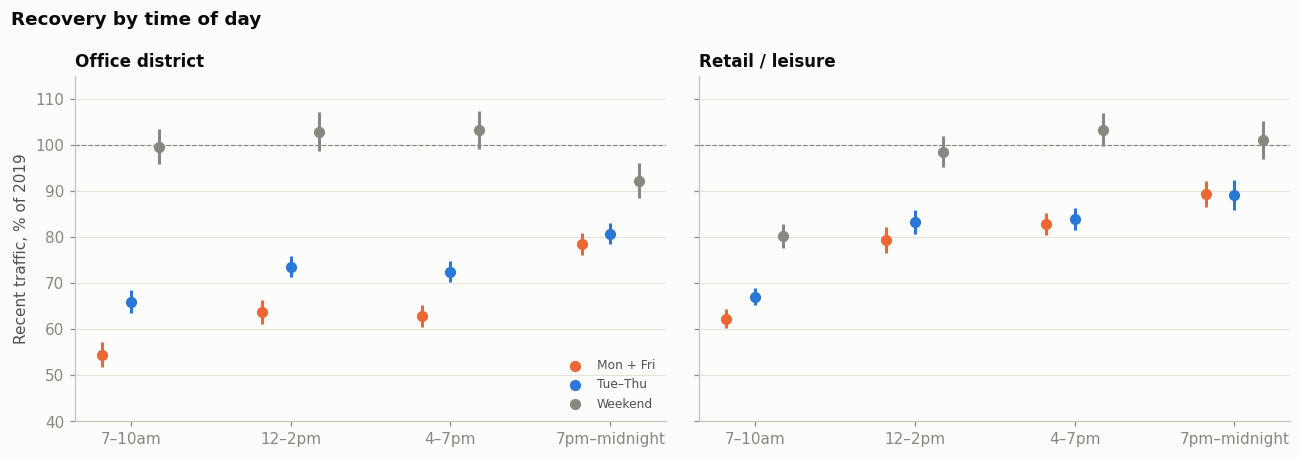

In [5]:
rows = []
for g, d in groups.items():
    for w, label in [("am_peak", "7–10am"), ("lunch", "12–2pm"), ("pm_peak", "4–7pm"), ("evening", "7pm–midnight")]:
        f = A.fit_recovery(d, w)
        for dg, wts in A.DAY_GROUPS.items():
            rows.append({"group": g, "window": label, "days": dg, **A.recovery(f, wts)})
tod = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
offsets = {"Mon + Fri": -0.18, "Tue–Thu": 0, "Weekend": 0.18}
colours = {"Mon + Fri": ORANGE, "Tue–Thu": BLUE, "Weekend": MUTED}
windows = tod.window.unique()
for ax, g in zip(axes, groups):
    for dg in offsets:
        t = tod[(tod.group == g) & (tod.days == dg)].set_index("window").loc[windows]
        x = np.arange(len(windows)) + offsets[dg]
        ax.vlines(x, t.low * 100, t.high * 100, color=colours[dg], lw=2)
        ax.scatter(x, t.ratio * 100, color=colours[dg], s=40, zorder=3, label=dg)
    ax.axhline(100, color=MUTED, lw=0.8, ls="--")
    ax.set_xticks(range(len(windows)), windows)
    ax.set_title(g, fontsize=11)
    ax.set_ylim(40, 115)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Recent traffic, % of 2019")
axes[0].legend(frameon=False, loc="lower right", fontsize=8)
fig.suptitle("Recovery by time of day", x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()

In [6]:
gaps = pd.DataFrame({
    (g, label): A.monfri_gap(A.fit_recovery(d, w))
    for g, d in groups.items()
    for w, label in [("daily", "whole day"), ("am_peak", "7–10am"), ("evening", "7pm–midnight")]
}).T
gaps[["gap", "low", "high"]].map(lambda v: f"{v:+.1%}").assign(p=gaps.p.map(lambda v: f"{v:.3g}"))

gap     low    high         p
Office district  whole day     -11.0%  -13.0%   -9.1%   2.7e-25
                 7–10am        -17.4%  -19.5%  -15.3%  6.27e-51
                 7pm–midnight   -2.7%   -5.9%   +0.6%     0.105
Retail / leisure whole day      -0.7%   -3.1%   +1.8%     0.592
                 7–10am         -7.2%   -9.1%   -5.3%  3.56e-13
                 7pm–midnight   +0.3%   -3.5%   +4.3%     0.868

**How to read this table:** `gap` is how much further Mon+Fri sit below 2019 than
Tue–Thu do. −17% for office sensors in the morning means: whatever Tue–Thu's
recovery is, Mon+Fri mornings are 17% lower again.

## 4. Robustness checks

Does the finding survive if we change the sample?

In [7]:
office = groups["Office district"]
upgraded = types.index[types.join(con.sql("SELECT location_id AS sensor_id, note FROM sensors").df().set_index("sensor_id")).note.fillna("").str.contains("Pushbox")]
checks = {
    "All office sensors": office,
    "…only sensors upgraded in 2023": office[office.sensor_id.isin(upgraded)],
    "…only sensors NOT upgraded": office[~office.sensor_id.isin(upgraded)],
    "…recent = Oct 2024 – Sep 2025": office[(office.period == "2019") | (office.date <= "2025-09-30")],
    "…recent = Oct 2025 – Sep 2026": office[(office.period == "2019") | (office.date >= "2025-10-01")],
}
rob = pd.DataFrame({
    name: {**{f"{k} vs 2019": A.recovery(A.fit_recovery(d), w)["ratio"] for k, w in A.DAY_GROUPS.items()},
           "Mon+Fri gap (7–10am)": A.monfri_gap(A.fit_recovery(d, "am_peak"))["gap"],
           "sensors": d.sensor_id.nunique()}
    for name, d in checks.items()
}).T
rob.assign(**{c: rob[c].map(pct) for c in rob.columns if c != "sensors"}, sensors=rob.sensors.astype(int))

,Mon + Fri vs 2019,Tue–Thu vs 2019,Weekend vs 2019,Mon+Fri gap (7–10am),sensors
All office sensors,64%,72%,101%,-17%,8
…only sensors upgraded in 2023,66%,76%,103%,-19%,3
…only sensors NOT upgraded,63%,70%,99%,-16%,5
…recent = Oct 2024 – Sep 2025,63%,72%,98%,-18%,8
…recent = Oct 2025 – Sep 2026,66%,73%,104%,-17%,8


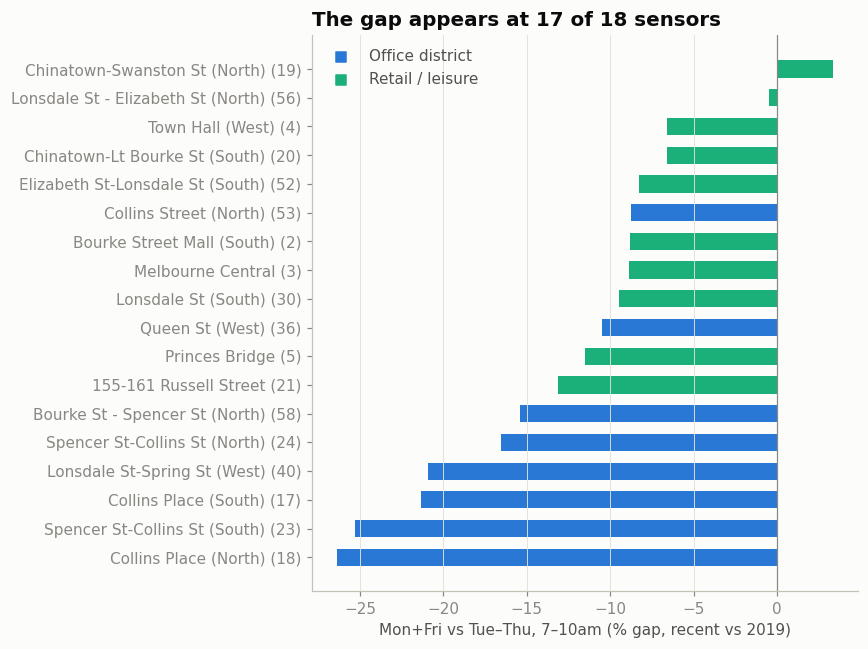

In [8]:
per_sensor = pd.Series({
    s: A.monfri_gap(A.fit_recovery(d, "am_peak"))["gap"] for s, d in days.groupby("sensor_id")
}).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
labels = [f"{names[s]} ({s})" for s in per_sensor.index]
colours = [BLUE if s in office_ids else AQUA for s in per_sensor.index]
ax.barh(labels, per_sensor * 100, color=colours, height=0.6)
ax.axvline(0, color=MUTED, lw=0.8)
ax.set_xlabel("Mon+Fri vs Tue–Thu, 7–10am (% gap, recent vs 2019)")
ax.set_title(f"The gap appears at {int((per_sensor < 0).sum())} of {len(per_sensor)} sensors")
ax.scatter([], [], color=BLUE, marker="s", label="Office district")
ax.scatter([], [], color=AQUA, marker="s", label="Retail / leisure")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 5. Finding

> **Weekend foot traffic in Melbourne's CBD is fully back to 2019 levels, but
> weekdays are not, and the gap is shaped by hybrid work.** In the office district,
> **Friday traffic is still 36% below 2019 and Monday 35% below, while Wednesday is
> 29% below and Thursday 26% below.** In the morning commute, Mondays and Fridays
> are a further 17% (95% CI 15–19%) below mid-week. The gap is the same in
> 2024–25 and 2025–26, so it looks settled rather than still closing.

Supporting evidence:
- **It's about commuting.** The gap is largest at 7–10am and disappears after 7pm.
  Retail and leisure sensors show no whole-day Mon/Fri gap.
- **It's widespread.** The morning gap appears at 17 of 18 sensors.
- **It's not the hardware.** Among office sensors, those upgraded in 2023 and those
  that weren't both show a large morning gap (−19% and −16%).
- **Retail is a different story.** At shopping and leisure sensors, Friday is the
  best-recovered weekday (85%), helped by Friday evenings out.

**Limitations**
- Sensors count people walking past, not unique visitors or office workers.
- 2019 vs recent compares different sensor hardware for some sensors; the upgrade
  check suggests this doesn't drive the result, but can't rule out every change.
- Nov 2022 – Sep 2024 is missing, so we can't see *when* the pattern settled.
- Other things changed since 2019 too (shops, transport, population), so this shows
  a pattern consistent with hybrid work, not proof of its cause.